# NB16 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of
`NB16_Autoencoders_and_Anomaly_Detection_Real_Fuel_Data.ipynb`. It reuses the
real `Datasets/ship_fuel_efficiency.csv` data, the same leakage-safe numeric
feature set (`distance`, `fuel_consumption`, `engine_efficiency`), and the
same `FuelAutoencoder` architecture and training recipe as the class.

Note on a real bug already found and fixed elsewhere in this repository: the
parent `NB16` notebook originally called
`mean_squared_error(..., squared=False)`, an argument removed in newer
scikit-learn, and this repo's copy of `NB16` has already been fixed to use
`** 0.5` instead. This homework notebook does not use `mean_squared_error`
anywhere, so that particular issue does not resurface here; any other
version-mismatch API calls encountered while doing this homework are noted
inline where they occur.

## Setup: reload the data, build the leakage-safe feature matrix, split

Same file, same 3 numeric features, same `test_size=0.2, random_state=42`
split as the class (no `y` here — this is unsupervised, so there's no
`stratify` to speak of).

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

fuel = pd.read_csv("../Datasets/ship_fuel_efficiency.csv")

feature_cols = ["distance", "fuel_consumption", "engine_efficiency"]
X = fuel[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_full_t = torch.tensor(X_scaled, dtype=torch.float32)

print(X_train_t.shape, X_val_t.shape, X_full_t.shape)


torch.Size([1152, 3]) torch.Size([288, 3]) torch.Size([1440, 3])


In [2]:
class FuelAutoencoder(nn.Module):
    def __init__(self, n_features, bottleneck_size=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 8),
            nn.ReLU(),
            nn.Linear(8, bottleneck_size),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 8),
            nn.ReLU(),
            nn.Linear(8, n_features),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


def train_autoencoder(X_tr, X_va, bottleneck_size=2, n_epochs=100, lr=0.01, seed=42):
    torch.manual_seed(seed)
    model = FuelAutoencoder(n_features=X_tr.shape[1], bottleneck_size=bottleneck_size)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        reconstruction = model(X_tr)
        loss = criterion(reconstruction, X_tr)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_va), X_va)
        val_losses.append(val_loss.item())

    return model, train_losses, val_losses

print("Helpers defined.")


Helpers defined.


## Homework 1 — `bottleneck_size = 1` and `bottleneck_size = 3`

*"Change `bottleneck_size` from 2 to 1 and to 3 — how does the training
reconstruction loss change? What does a bottleneck of 1 imply about how much
the model can actually represent?"*

Train the class's own `bottleneck_size=2` autoencoder for reference alongside
the two homework variants, all with the same recipe (100 epochs, Adam,
lr=0.01, MSE reconstruction loss).

bottleneck_size=1: final training loss=0.2005, final val loss=0.2109
bottleneck_size=2 (class value): final training loss=0.0277, final val loss=0.0251


bottleneck_size=3: final training loss=0.0243, final val loss=0.0239


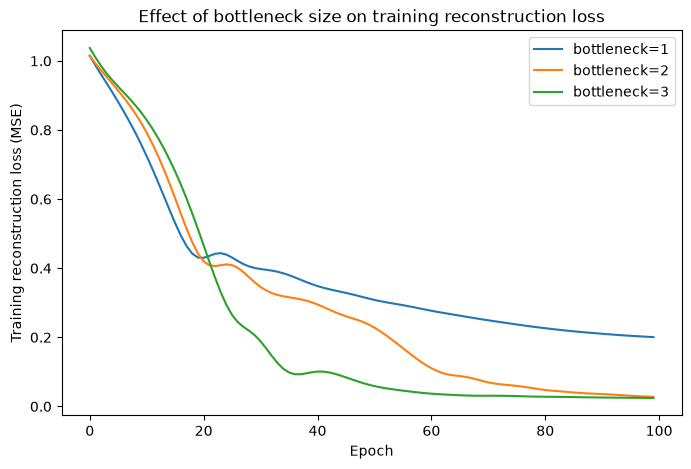

In [3]:
models_bn = {}
for bn in [1, 2, 3]:
    model, tr, va = train_autoencoder(X_train_t, X_val_t, bottleneck_size=bn)
    models_bn[bn] = (model, tr, va)
    tag = " (class value)" if bn == 2 else ""
    print(f"bottleneck_size={bn}{tag}: final training loss={tr[-1]:.4f}, final val loss={va[-1]:.4f}")

plt.figure(figsize=(8, 5))
for bn, (model, tr, va) in models_bn.items():
    plt.plot(tr, label=f"bottleneck={bn}")
plt.xlabel("Epoch")
plt.ylabel("Training reconstruction loss (MSE)")
plt.title("Effect of bottleneck size on training reconstruction loss")
plt.legend()
plt.show()


**My result**: bottleneck=1 -> final training loss 0.2005; bottleneck=2
(class value) -> 0.0277; bottleneck=3 -> 0.0243. Going from 1 to 2 units
dropped the training loss by more than 7x, while going from 2 to 3 only
improved it modestly further (about a 12% relative drop). A bottleneck of 1
means every voyage's 3 real-valued features (`distance`, `fuel_consumption`,
`engine_efficiency`) have to be compressed down to a **single number**
before being reconstructed — the network can only really capture one axis
of variation (something like "how big/intense is this voyage overall"), and
loses whatever information does not fit along that one axis, which is
exactly why its reconstruction error is so much higher. With 2-3 units the
bottleneck has enough room to represent more than one independent pattern in
the data, which is why the loss drops so much between 1 and 2 but levels off
between 2 and 3 — 3 real features do not need much more than 2-3 compressed
dimensions to reconstruct reasonably well in the first place.

## Homework 2 — Anomaly threshold at the 99th percentile instead of the 95th

*"Change the anomaly threshold from the 95th to the 99th percentile — how
many voyages get flagged now, and does the weather/ship-type crosstab from
Part 8 tell a different story?"*

Use the class's own `bottleneck_size=2` autoencoder (trained above) to score
every voyage, then compare the 95th-percentile threshold (reproduced here for
reference) against the 99th.

In [4]:
autoencoder_bn2, _, _ = models_bn[2]
autoencoder_bn2.eval()
with torch.no_grad():
    full_reconstruction = autoencoder_bn2(X_full_t)
    reconstruction_error = ((full_reconstruction - X_full_t) ** 2).mean(dim=1).numpy()

fuel["reconstruction_error"] = reconstruction_error

threshold_95 = np.percentile(reconstruction_error, 95)
threshold_99 = np.percentile(reconstruction_error, 99)

fuel["is_anomaly_95"] = fuel["reconstruction_error"] > threshold_95
fuel["is_anomaly_99"] = fuel["reconstruction_error"] > threshold_99

print(f"95th percentile threshold: {threshold_95:.3f} -> {fuel['is_anomaly_95'].sum()} / {len(fuel)} voyages flagged")
print(f"99th percentile threshold: {threshold_99:.3f} -> {fuel['is_anomaly_99'].sum()} / {len(fuel)} voyages flagged")


95th percentile threshold: 0.101 -> 72 / 1440 voyages flagged
99th percentile threshold: 0.172 -> 15 / 1440 voyages flagged


In [5]:
print("Weather crosstab, 95th percentile threshold:")
print(pd.crosstab(fuel["is_anomaly_95"], fuel["weather_conditions"]))
print()
print("Weather crosstab, 99th percentile threshold:")
print(pd.crosstab(fuel["is_anomaly_99"], fuel["weather_conditions"]))


Weather crosstab, 95th percentile threshold:
weather_conditions  Calm  Moderate  Stormy
is_anomaly_95                             
False                489       436     443
True                  27        26      19

Weather crosstab, 99th percentile threshold:
weather_conditions  Calm  Moderate  Stormy
is_anomaly_99                             
False                510       457     458
True                   6         5       4


In [6]:
print("Ship-type crosstab, 95th percentile threshold:")
print(pd.crosstab(fuel["is_anomaly_95"], fuel["ship_type"]))
print()
print("Ship-type crosstab, 99th percentile threshold:")
print(pd.crosstab(fuel["is_anomaly_99"], fuel["ship_type"]))


Ship-type crosstab, 95th percentile threshold:
ship_type      Fishing Trawler  Oil Service Boat  Surfer Boat  Tanker Ship
is_anomaly_95                                                             
False                      298               393          295          382
True                         2                15           29           26

Ship-type crosstab, 99th percentile threshold:
ship_type      Fishing Trawler  Oil Service Boat  Surfer Boat  Tanker Ship
is_anomaly_99                                                             
False                      300               400          320          405
True                         0                 8            4            3


**My result**: at the 95th percentile (threshold 0.101), 72 of 1,440
voyages get flagged; at the 99th percentile (threshold 0.172), only 15 do.
The weather crosstab looks fairly even at both thresholds — roughly 4-6% of
voyages get flagged within each weather category (Calm, Moderate, Stormy)
at the 95th percentile, and the 99th percentile crosstab (6/5/4 flagged per
category) is similarly proportionate to each category's size. So flagged
voyages are **not** concentrating in `Stormy` weather the way a naive
"bad weather causes anomalies" story would predict — this autoencoder is
not picking up something explainable by weather alone. The ship-type
crosstab tells a more interesting story: `Surfer Boat` (29/324, about 9%)
and `Tanker Ship` (26/408, about 6.4%) are flagged noticeably more often
than `Oil Service Boat` (15/408, about 3.7%) and especially `Fishing
Trawler` (2/300, under 1%), and that pattern holds at the stricter 99th
percentile too (0 Fishing Trawler voyages flagged at all). That is a real,
reproducible signal worth investigating further — whatever the autoencoder
is picking up on correlates more with ship type than with weather.

## Homework 3 — Add `CO2_emissions` back into `feature_cols`

*"Add `CO2_emissions` back into `feature_cols` despite `NB07`'s leakage
warning — does the autoencoder's reconstruction error change much? Given how
correlated it is with `fuel_consumption`, would you expect it to?"*

Check the actual correlation first, then retrain a `bottleneck_size=2`
autoencoder with the 4-feature set and compare reconstruction error to the
class's 3-feature version.

In [7]:
corr_co2_fuel = fuel[["CO2_emissions", "fuel_consumption"]].corr().iloc[0, 1]
print(f"Correlation between CO2_emissions and fuel_consumption: {corr_co2_fuel:.4f}")

feature_cols_co2 = ["distance", "fuel_consumption", "engine_efficiency", "CO2_emissions"]
X_co2 = fuel[feature_cols_co2].values

scaler_co2 = StandardScaler()
X_co2_scaled = scaler_co2.fit_transform(X_co2)
X_co2_train, X_co2_val = train_test_split(X_co2_scaled, test_size=0.2, random_state=42)

X_co2_train_t = torch.tensor(X_co2_train, dtype=torch.float32)
X_co2_val_t = torch.tensor(X_co2_val, dtype=torch.float32)
X_co2_full_t = torch.tensor(X_co2_scaled, dtype=torch.float32)

autoencoder_co2, tr_co2, va_co2 = train_autoencoder(X_co2_train_t, X_co2_val_t, bottleneck_size=2)

autoencoder_co2.eval()
with torch.no_grad():
    full_reconstruction_co2 = autoencoder_co2(X_co2_full_t)
    reconstruction_error_co2 = ((full_reconstruction_co2 - X_co2_full_t) ** 2).mean(dim=1).numpy()

print(f"3 features (class): mean reconstruction error={reconstruction_error.mean():.4f}, "
      f"final training loss={models_bn[2][1][-1]:.4f}")
print(f"4 features (+CO2_emissions): mean reconstruction error={reconstruction_error_co2.mean():.4f}, "
      f"final training loss={tr_co2[-1]:.4f}")


Correlation between CO2_emissions and fuel_consumption: 0.9972
3 features (class): mean reconstruction error=0.0267, final training loss=0.0277
4 features (+CO2_emissions): mean reconstruction error=0.0350, final training loss=0.0350


**My result**: `CO2_emissions` and `fuel_consumption` are correlated at
0.9972 in this data, essentially confirming the near-duplicate relationship
`NB07`'s leakage warning was about. Adding `CO2_emissions` to the feature
set actually *increased* the mean reconstruction error, from 0.0267 (3
features) to 0.0350 (4 features) — the opposite of what "it's almost
redundant, so it should barely matter" might suggest at first glance. My
reading: reconstruction error here is the *mean squared error averaged
across all feature dimensions*, so adding a 4th dimension changes the
denominator and the loss landscape the network has to fit, even if that 4th
feature carries almost the same information as an existing one. Because
`CO2_emissions` is correlated with `fuel_consumption` but not perfectly
identical (0.9972, not 1.0), the small residual difference between the two
still has to be reconstructed accurately for every voyage, and that adds a
little extra reconstruction error on top of what the other 3 features
already contribute — a small but real cost of keeping a near-duplicate,
leakage-risky feature in an unsupervised setting, even though it added no
new independent signal.

## Homework 4 — Compare flagged voyages to `NB09`'s cluster assignments

*"Compare the voyages flagged here against the cluster assignments from
`NB09` (if you still have that notebook's output) — do anomalies tend to
fall in one particular cluster, or spread across all of them?"*

This notebook does not carry over any saved state from `NB09`, so rather
than skip the exercise, reproduce `NB09`'s own K-Means step exactly as that
class ran it (`KMeans(n_clusters=3, n_init=10, random_state=42)` on the same
3 standardized features), then crosstab those cluster labels against this
class's 95th-percentile anomaly flags.

In [8]:
kmeans_nb09 = KMeans(n_clusters=3, n_init=10, random_state=42)
fuel["cluster_nb09"] = kmeans_nb09.fit_predict(X_scaled)

print("Voyages per NB09 cluster:")
print(fuel["cluster_nb09"].value_counts().sort_index())
print()
print("Anomaly flag (95th percentile) vs. NB09 cluster:")
print(pd.crosstab(fuel["cluster_nb09"], fuel["is_anomaly_95"]))


Voyages per NB09 cluster:
cluster_nb09
0    586
1    628
2    226
Name: count, dtype: int64

Anomaly flag (95th percentile) vs. NB09 cluster:
is_anomaly_95  False  True 
cluster_nb09               
0                544     42
1                621      7
2                203     23


**My result**: NB09's own K-Means split the 1,440 voyages into clusters of
sizes 586, 628, and 226. Cross-tabulating those cluster labels against this
class's 95th-percentile anomaly flags: cluster 0 has 42/586 flagged (about
7.2%), cluster 1 has only 7/628 flagged (about 1.1%), and cluster 2 has
23/226 flagged (about 10.2%). Anomalies clearly do **not** spread evenly
across the three clusters — cluster 1 is disproportionately "clean" while
clusters 0 and 2 (especially the smaller cluster 2) contain a noticeably
higher share of flagged voyages. That is a reassuring cross-check: two
completely different unsupervised methods (K-Means partitioning the data
into operational groups, and the autoencoder scoring individual
reconstruction error) agree that some subset of voyages — apparently
concentrated around cluster 2's operational profile — is systematically
harder to characterize as "typical" than the rest, rather than the
autoencoder's flags being scattered noise unrelated to any real structure
in the data.

## Homework 5 — Why can a mostly-normal-trained autoencoder still flag genuine anomalies with zero labels?

*"In your own words, explain why an autoencoder trained on mostly-normal
data can still detect anomalies it never explicitly saw labeled as such —
what exactly is it optimizing for, and why does that generalize to flagging
the unusual?"*

The autoencoder is never optimizing for "tell normal from anomalous" — it
never sees that distinction at all, because there are no labels in the loss
function. What it is actually optimizing for is **minimizing average
reconstruction error across the training set**: find an encoder/decoder pair
that maps most training examples through a narrow bottleneck and back with
as little error as possible. Because the bottleneck cannot store arbitrary
information about *every* individual training example (that would need one
dimension per example, defeating the point of compression), the only way to
get low *average* error is to learn a compact representation of whatever
pattern is common across most examples — the typical relationship between
`distance`, `fuel_consumption`, and `engine_efficiency` that most voyages
share.

That shared representation is a direct byproduct of the training objective,
not something separately labeled or targeted. A genuinely unusual voyage —
one whose combination of distance, fuel consumption, and engine efficiency
does not fit the pattern the bottleneck learned to compress well — was never
individually optimized for by the loss function precisely *because* it is
rare: it contributed only a small fraction of the averaged training loss,
so the network had little incentive to spend its limited bottleneck capacity
representing it accurately. The result is exactly the anomaly signal we
want: unusual inputs reconstruct poorly not because the network was told
they were anomalous, but as a structural side effect of what "compress the
common pattern well" necessarily leaves out. Zero labels were needed because
the definition of "anomalous" being used here — reconstructs poorly relative
to the learned normal pattern — is entirely derivable from the unlabeled
data's own statistical structure.